In [1]:
from google.colab import drive
drive.mount('/content/drive')

# Import the Pandas library
import pandas as pd

# load the file from google drive
claim_cleaned_df_path = "/content/drive/My Drive/SBD_CAPSTONE/Cleaned_Data/claim_cleaned_df.csv"

# Load the file using read_csv since it's a CSV file
claim_cleaned_df = pd.read_csv(claim_cleaned_df_path)

# Display the first few rows of the dataframe
print(claim_cleaned_df.head())



Mounted at /content/drive
   Claim Number Model Number    Warranty Item Description Serial Number  \
0      71692559  55RK6HNR050  MOWER:CWB:36 HYD2800 RECOIL   1B198H70003   
1      71698531  55RK6HNR050  MOWER:CWB:36 HYD2800 RECOIL   1B198H70003   
2      71700308  55RK6HNR050  MOWER:CWB:36 HYD2800 RECOIL   1B198H70003   
3      71707104  55RK6HNR050  MOWER:CWB:36 HYD2800 RECOIL   1B198H70003   
4      71726990  55RK6HNR050  MOWER:CWB:36 HYD2800 RECOIL   1B158H70028   

   Engine Model Transmission Model Repair Dealer Number  \
0  752SFS481S33          618-07347               S76489   
1  752SFS481S33          618-07347               S76489   
2  752SFS481S33          618-07347               S76489   
3  752SFS481S33          618-07347               S76489   
4  752SFS481S33          618-07347               S77690   

                  Owner City Owner State Owner Zip Purchase Date Failure Date  \
0  ANDOVER                            KS     67002     7/13/2019    7/18/2020   
1  AND

In [2]:
from google.colab import drive
drive.mount('/content/drive')
import pandas as pd

# load the failure part cleaned data path from google drive
failure_part_cleaned_path = "/content/drive/My Drive/SBD_CAPSTONE/Cleaned_Data/failure_part_cleaned_df.csv"
failure_part_cleaned_df = pd.read_csv(failure_part_cleaned_path)

# display first few rows of the data
print(failure_part_cleaned_df.head())

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
   Unnamed: 0  Failure Part id   Claim Number             Failure Description  \
0           0                 1      20028686  Loose                            
1           1                 2      20032406  Damaged at Factory               
2           2                 3      20032941  Will not Charge                  
3           3                 4      30843126  Cracked                          
4           4                 5      20033818  Incorrect Part                   

  Failure Part        Failure Part Description  \
0   757-04083A   SEAT:3400:MED BACK:BLK NO OPS   
1    925-04347                SW:KEY:MOMENTARY   
2    925-1707D  BAT:U1:300 CCA DRY VENTED T UD   
3    753-06687             SHBLK:FC27CC:SC BLO   
4    951-12725  CAP:FUEL:3.50" ONEWAY VENT FKM   

                                 Complaint Diagnosis  \
0                      guid

In [3]:
# load the replacement part data path from google drive
replacement_part_cleaned_data = "/content/drive/My Drive/SBD_CAPSTONE/Cleaned_Data/replacement_part_cleaned_df.csv"
replacement_part_cleaned_df = pd.read_csv(replacement_part_cleaned_data)

# display first few rows of the data
print(replacement_part_cleaned_df.head())


   Unnamed: 0  Claim Number  Replacement Part id Replacement Part  \
0           0      20028686                    1       757-04083A   
1           1      20032406                    2        925-04347   
2           2      20032941                    3        925-1707D   
3           3      30843126                    4        753-06687   
4           4      20033818                    5        951-12725   

     Replacement Part Description  Part Quantity  Part Price  \
0   SEAT:3400:MED BACK:BLK NO OPS              1      169.07   
1                SW:KEY:MOMENTARY              1       22.24   
2  BAT:U1:300 CCA DRY VENTED T UD              1       49.06   
3             SHBLK:FC27CC:SC BLO              1        0.00   
4  CAP:FUEL:3.50" ONEWAY VENT FKM              2       51.59   

   Part Extended Price  Labor Rate  Paid Labor Hours  Total Failure Cost  
0               169.07          60              0.50              199.07  
1                22.24          60              0.

In [4]:
# check info of claim data
claim_cleaned_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 375364 entries, 0 to 375363
Data columns (total 16 columns):
 #   Column                           Non-Null Count   Dtype  
---  ------                           --------------   -----  
 0   Claim Number                     375364 non-null  int64  
 1   Model Number                     375348 non-null  object 
 2   Warranty Item Description        375364 non-null  object 
 3   Serial Number                    374033 non-null  object 
 4   Engine Model                     333224 non-null  object 
 5   Transmission Model               277260 non-null  object 
 6   Repair Dealer Number             368636 non-null  object 
 7   Owner City                       305478 non-null  object 
 8   Owner State                      305381 non-null  object 
 9   Owner Zip                        305481 non-null  object 
 10  Purchase Date                    375349 non-null  object 
 11  Failure Date                     375362 non-null  object 
 12  Re

# Exploratory Data Analysis (EDA) - Claims Data

## Model Numbers with Most number of claims

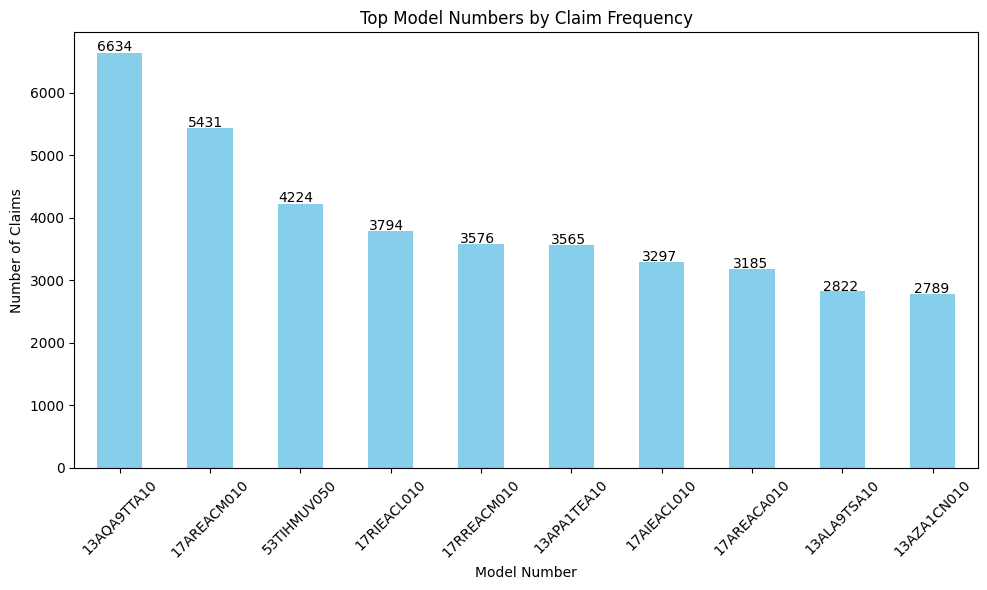

In [5]:
# Check the Model Numbers with most claims

# Import necessary libraries

import pandas as pd
import matplotlib.pyplot as plt

# Count unique claim numbers for each model number
model_claims_count = claim_cleaned_df.groupby('Model Number')['Claim Number'].nunique()

# Sort the data to find the top models with the most claims
model_claims_count = model_claims_count.sort_values(ascending=False)

# Plot the top 10 model numbers with the most claims
top_n = 10  # we are finding the top 10 models
top_model_claims_count = model_claims_count.head(top_n)
ax = top_model_claims_count.plot(kind='bar', color='skyblue', figsize=(10, 6))

plt.title('Top Model Numbers by Claim Frequency')
plt.xlabel('Model Number')
plt.ylabel('Number of Claims')
plt.xticks(rotation=45)  # Rotate model numbers for better readability

# Adding the text labels on the bars
for p in ax.patches:
    ax.annotate(str(p.get_height()), (p.get_x() * 1.005, p.get_height() * 1.005))

plt.tight_layout()
plt.show()


## Model Numbers with Most number of claims along with Total Claim Dollars

<ipython-input-6-bf96b79a5a81>:19: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax1.set_xticklabels(top_models['Model Number'], rotation=45, ha='right')


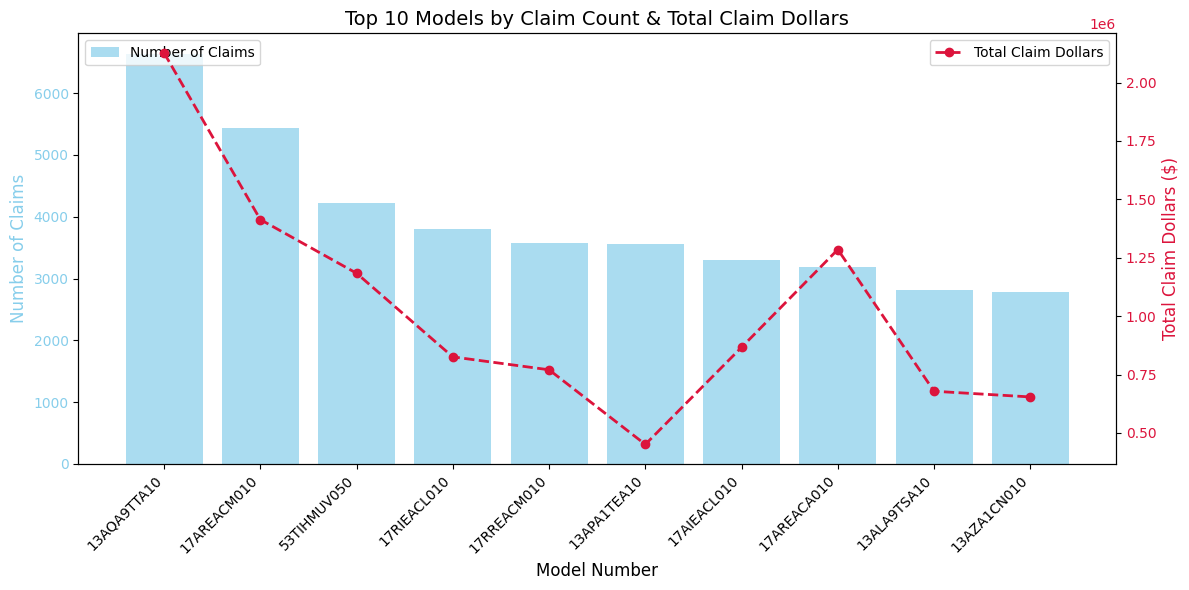

In [6]:
# Group data to get both claim frequency and total claim dollars per model
model_claims = claim_cleaned_df.groupby('Model Number').agg(
    Claim_Count=('Claim Number', 'count'),
    Total_Claim_Dollars=('Total Claim Dollars', 'sum')
).reset_index()

# Select top 10 models based on claim count
top_models = model_claims.nlargest(10, 'Claim_Count')

# Plot with dual-axis for better insights
fig, ax1 = plt.subplots(figsize=(12, 6))

# Bar plot for claim count
color1 = 'skyblue'
ax1.bar(top_models['Model Number'], top_models['Claim_Count'], color=color1, alpha=0.7, label='Number of Claims')
ax1.set_xlabel('Model Number', fontsize=12)
ax1.set_ylabel('Number of Claims', fontsize=12, color=color1)
ax1.tick_params(axis='y', labelcolor=color1)
ax1.set_xticklabels(top_models['Model Number'], rotation=45, ha='right')

# Secondary Y-axis for Total Claim Dollars
ax2 = ax1.twinx()
color2 = 'crimson'
ax2.plot(top_models['Model Number'], top_models['Total_Claim_Dollars'], color=color2, marker='o', linestyle='dashed', linewidth=2, label='Total Claim Dollars')
ax2.set_ylabel('Total Claim Dollars ($)', fontsize=12, color=color2)
ax2.tick_params(axis='y', labelcolor=color2)

# Title and legend
plt.title('Top 10 Models by Claim Count & Total Claim Dollars', fontsize=14)
fig.tight_layout()
ax1.legend(loc='upper left')
ax2.legend(loc='upper right')

# Show plot
plt.show()


## Identify if there are any serial numbers that's of serious concern

In [7]:
import pandas as pd
import matplotlib.pyplot as plt

# Identify the top 50 most common Serial Numbers
top_serials = claim_cleaned_df['Serial Number'].value_counts().nlargest(50).index

# Filter the DataFrame to include only the top 50 serial numbers
claim_data_top_50_serials = claim_cleaned_df[claim_cleaned_df['Serial Number'].isin(top_serials)]

# Aggregate the number of unique claims and total claim dollars for each serial number
aggregated_data = claim_data_top_50_serials.groupby('Serial Number').agg({
    'Claim Number': 'nunique',  # Count unique claims
    'Total Claim Dollars': 'sum'  # Sum of total claim dollars
}).rename(columns={'Claim Number': 'Number of Claims'})

# Sort by number of claims for better visualization
aggregated_data = aggregated_data.sort_values(by='Number of Claims', ascending=False)

# Display the aggregated data
print(aggregated_data.head(50))


               Number of Claims  Total Claim Dollars
Serial Number                                       
1J058H70013                  22              5241.69
1K078H70005                  22             10601.73
1L129H70021                  20              3143.74
1E11MH70017                  20              5340.58
1A220H70014                  20              6858.78
1H25NH70028                  19              6534.42
1G19NH70009                  19              9186.53
1D21MH70012                  19              9679.89
1J039H70019                  18              6346.36
1C15MH70001                  17              4872.77
1E229H70010                  17              5261.02
1L129H70004                  17              6910.81
1H19MH70013                  16              5309.96
1J099H70012                  16              3859.59
1K098H70001                  16             14240.10
1H056H70017                  16              8085.46
1J259H70006                  16              2

## Plot a Graph of top 50 serial numbers along with their total claim dollar value

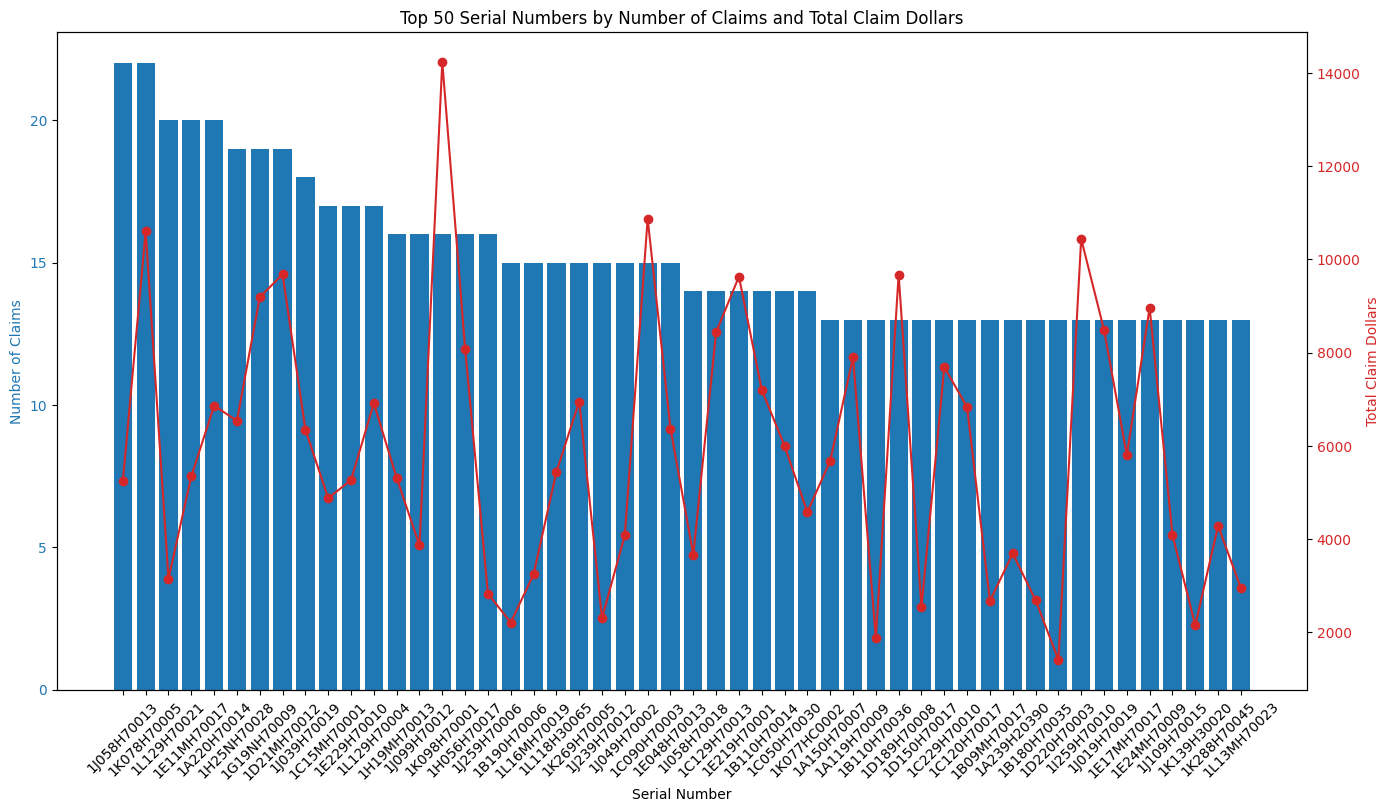

In [8]:
fig, ax1 = plt.subplots(figsize=(14, 8))

# Bar plot for the number of claims
color = 'tab:blue'
ax1.set_xlabel('Serial Number')
ax1.set_ylabel('Number of Claims', color=color)
ax1.bar(aggregated_data.index, aggregated_data['Number of Claims'], color=color)
ax1.tick_params(axis='y', labelcolor=color)
ax1.tick_params(axis='x', rotation=45)  # Rotate x labels for better visibility

# Instantiate a second axes that shares the same x-axis
ax2 = ax1.twinx()
color = 'tab:red'
ax2.set_ylabel('Total Claim Dollars', color=color)  # we already handled the x-label with ax1
ax2.plot(aggregated_data.index, aggregated_data['Total Claim Dollars'], color=color, marker='o', linestyle='-')
ax2.tick_params(axis='y', labelcolor=color)

fig.tight_layout()  # to ensure the layout doesn't get messed up
plt.title('Top 50 Serial Numbers by Number of Claims and Total Claim Dollars')
plt.show()


## Plot a graph to see which states are having the highest number of claims based on claim count

Owner State
OH    21690
QC    19954
ON    15827
PA    14150
TX    13501
NC    12742
MI    12339
KY    11884
NY    11796
TN    11155
Name: Claim Number, dtype: int64


<ipython-input-9-9c4408545b95>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states.index, y=top_states.values, palette='coolwarm')


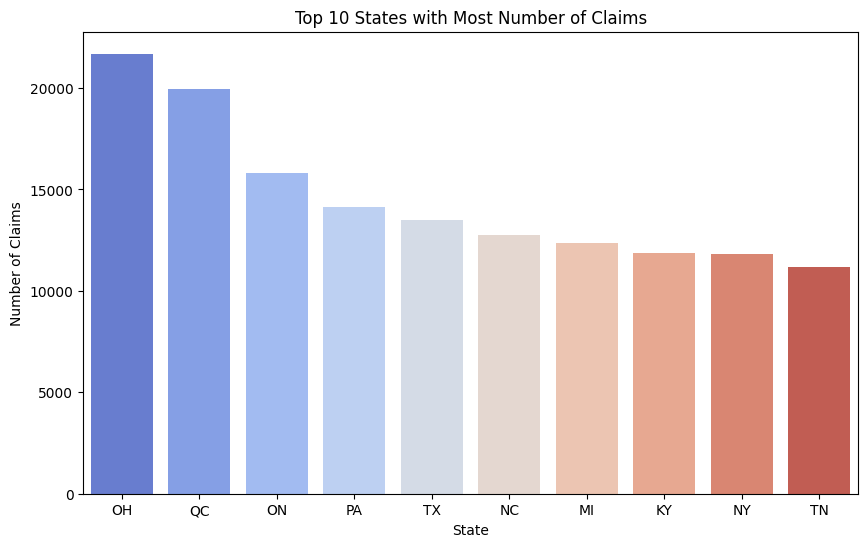

In [9]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


# Count claims by state
state_claims = claim_cleaned_df.groupby('Owner State')['Claim Number'].nunique()

# Get the top 10 states with the most claims
top_states = state_claims.sort_values(ascending=False).head(10)

# Print top 10 states
print(top_states)

# Create a bar chart
plt.figure(figsize=(10, 6))
sns.barplot(x=top_states.index, y=top_states.values, palette='coolwarm')

# Adding labels and title
plt.title('Top 10 States with Most Number of Claims')
plt.xlabel('State')
plt.ylabel('Number of Claims')

# Display the plot
plt.show()


## Plot Top 10 states by total claim dollars

Owner State
OH    5079999.40
TX    3699572.32
PA    3285251.05
NC    3218317.77
KY    3101238.75
TN    3065369.90
FL    2833702.44
MI    2760141.75
NY    2714589.88
VA    2488357.84
Name: Total Claim Dollars, dtype: float64


<ipython-input-10-9c1665318872>:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_states_by_dollars.index, y=top_states_by_dollars.values, palette='magma')


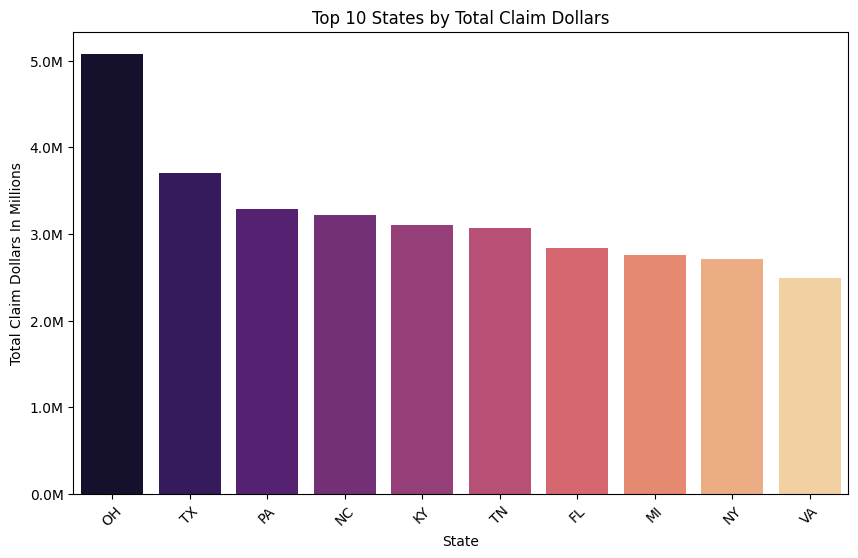

In [10]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Sum total claim dollars by state
state_total_claims = claim_cleaned_df.groupby('Owner State')['Total Claim Dollars'].sum()

# Get the top 10 states with the highest total claim dollars
top_states_by_dollars = state_total_claims.sort_values(ascending=False).head(10)

# Print the results
print(top_states_by_dollars)

# Plot the graph
plt.figure(figsize=(10, 6))
sns.barplot(x=top_states_by_dollars.index, y=top_states_by_dollars.values, palette='magma')
plt.title('Top 10 States by Total Claim Dollars')
plt.xlabel('State')
plt.ylabel('Total Claim Dollars In Millions')
plt.xticks(rotation=45)

# Format y-axis to show values in millions (M)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

plt.show()


## Plot Yearly Distribution of Total Claim Dollars

<ipython-input-11-be32f88b9bb9>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=yearly_claims['Repair Date'], y=yearly_claims['Total Claim Dollars'], palette='coolwarm')


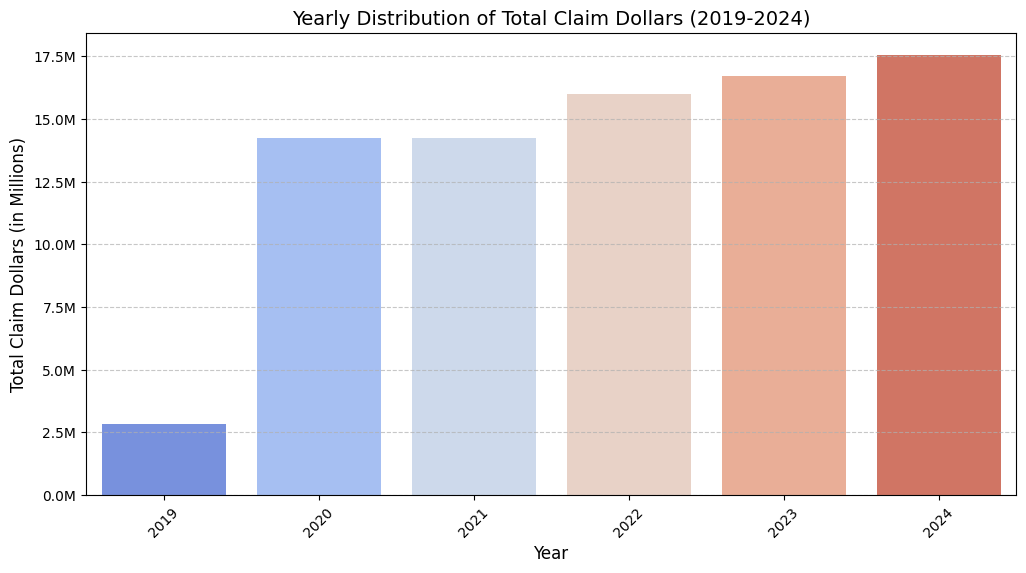

In [11]:
import matplotlib.ticker as ticker

# change repair date to datetime format
claim_cleaned_df['Repair Date'] = pd.to_datetime(claim_cleaned_df['Repair Date'], errors='coerce')

# Group the data by year and sum total claim dollars
yearly_claims = claim_cleaned_df.groupby(claim_cleaned_df['Repair Date'].dt.year)['Total Claim Dollars'].sum().reset_index()

# Plotting
plt.figure(figsize=(12, 6))
sns.barplot(x=yearly_claims['Repair Date'], y=yearly_claims['Total Claim Dollars'], palette='coolwarm')

# add Labels and title
plt.xlabel('Year', fontsize=12)
plt.ylabel('Total Claim Dollars (in Millions)', fontsize=12)
plt.title('Yearly Distribution of Total Claim Dollars (2019-2024)', fontsize=14)
plt.xticks(rotation=45)

# Format y-axis to show values in millions (M)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

# Add gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()


## Plot the monthly distribution of total claim dollars

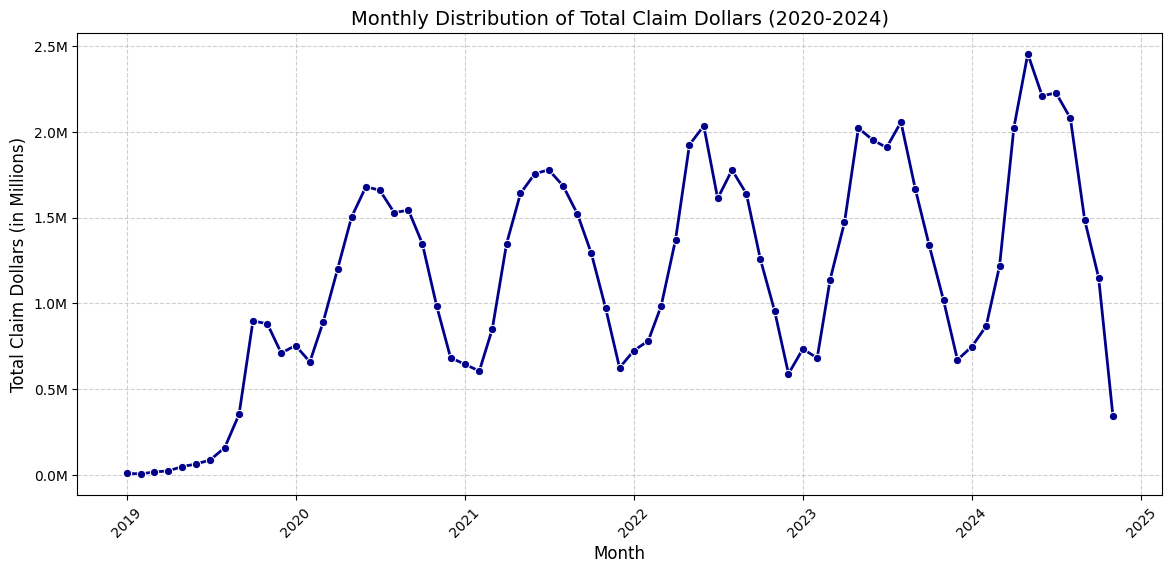

In [12]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# change the Failure Date to datetime format
claim_cleaned_df['Failure Date'] = pd.to_datetime(claim_cleaned_df['Failure Date'], errors='coerce')

# Filter the DataFrame to include only dates after 2019
claim_cleaned_df = claim_cleaned_df[claim_cleaned_df['Failure Date'].dt.year >= 2019]

# Group by month and year to get total claim dollars
monthly_claims = claim_cleaned_df.groupby(claim_cleaned_df['Failure Date'].dt.to_period('M'))['Total Claim Dollars'].sum().reset_index()

# Convert period to datetime for plotting
monthly_claims['Failure Date'] = monthly_claims['Failure Date'].astype(str)
monthly_claims['Failure Date'] = pd.to_datetime(monthly_claims['Failure Date'])

# Plotting Monthly Trends
plt.figure(figsize=(14, 6))
sns.lineplot(x=monthly_claims['Failure Date'], y=monthly_claims['Total Claim Dollars'], marker='o', color='darkblue', linewidth=2)

# Labels and title
plt.xlabel('Month', fontsize=12)
plt.ylabel('Total Claim Dollars (in Millions)', fontsize=12)
plt.title('Monthly Distribution of Total Claim Dollars (2020-2024)', fontsize=14)
plt.xticks(rotation=45)

# Format y-axis to show values in millions (M)
plt.gca().yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

# Add gridlines for better readability
plt.grid(axis='both', linestyle='--', alpha=0.6)

# Show plot
plt.show()


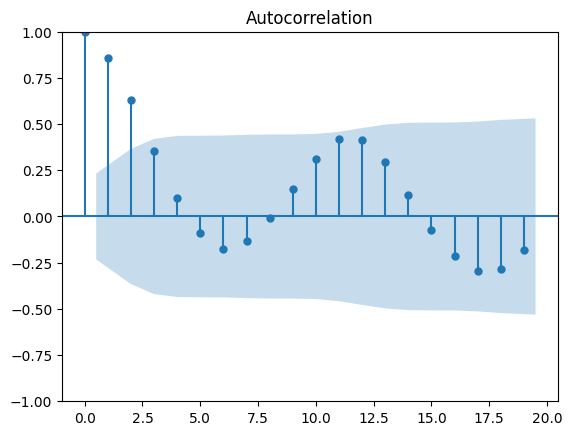

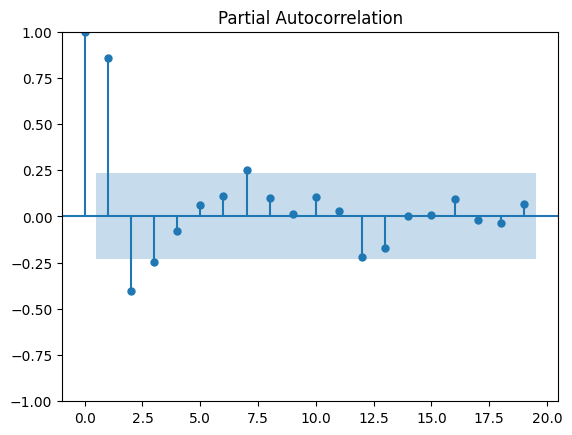

In [13]:
# check autocorrelation and partial autocorrelation plots to check for seasonal factors

from statsmodels.graphics.tsaplots import plot_acf, plot_pacf

plot_acf(monthly_claims['Total Claim Dollars'])
plt.show()

plot_pacf(monthly_claims['Total Claim Dollars'])
plt.show()


Based on above plots we can say that

1. There is a strong autocorrelation at the first few lags.

2. There is a strong seasonal or cyclic patterns in the data

3. Suggest that ARIMA model might be a better fit.

## Plot the Seasonal Trend Decomposition of Total Claim Dollars

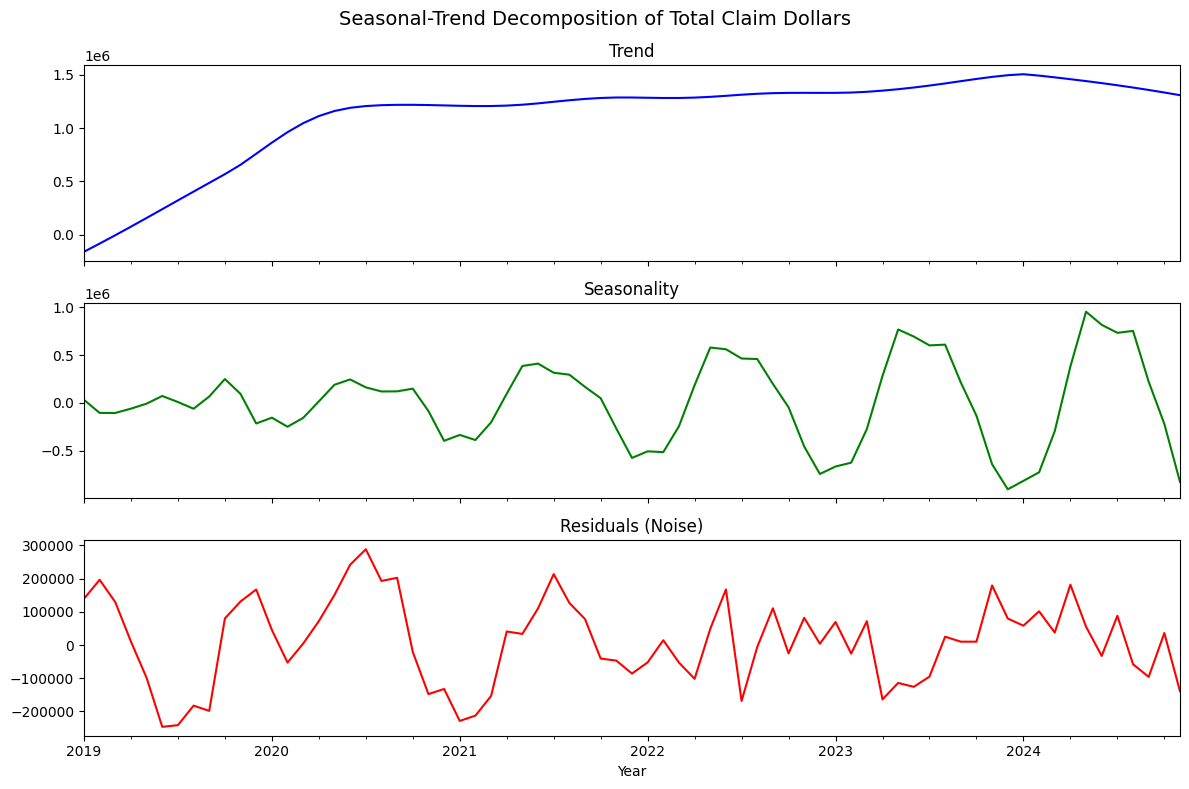

In [14]:
import statsmodels.api as sm

# make sure Failure Date is in datetime format and set as index
monthly_claims['Failure Date'] = pd.to_datetime(monthly_claims['Failure Date'])
monthly_claims.set_index('Failure Date', inplace=True)

# Seasonal-Trend Decomposition
# Explicitly set the period
stl = sm.tsa.STL(monthly_claims['Total Claim Dollars'], seasonal=13, period=12)
result = stl.fit()

# Plot the decomposition results
fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

# Plot each component
result.trend.plot(ax=axes[0], title='Trend', color='blue')
result.seasonal.plot(ax=axes[1], title='Seasonality', color='green')
result.resid.plot(ax=axes[2], title='Residuals (Noise)', color='red')

# Formatting
plt.xlabel('Year')
plt.suptitle('Seasonal-Trend Decomposition of Total Claim Dollars', fontsize=14)
plt.tight_layout()

# Show plot
plt.show()

## Plot the Yearly distribution of total claim count

<ipython-input-15-3138d3d96c13>:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(x=yearly_claim_trend['Repair Date'], y=yearly_claim_trend['Claim Number'], palette='Blues_r')


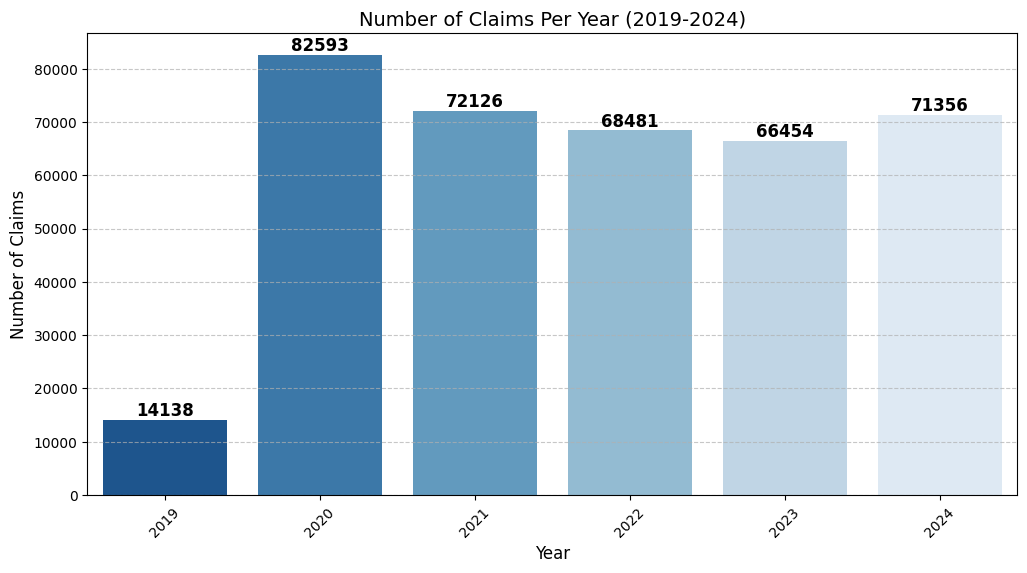

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

# Group by the data year and count the number of claims
yearly_claim_trend = claim_cleaned_df.groupby(claim_cleaned_df['Repair Date'].dt.year)['Claim Number'].count().reset_index()

# Plot the trend over the years
plt.figure(figsize=(12, 6))
ax = sns.barplot(x=yearly_claim_trend['Repair Date'], y=yearly_claim_trend['Claim Number'], palette='Blues_r')

# Add value labels on top of each bar
for p in ax.patches:
    ax.annotate(f'{int(p.get_height())}',
                (p.get_x() + p.get_width() / 2, p.get_height()),
                ha='center', va='bottom', fontsize=12, fontweight='bold')

# Labels and title
plt.xlabel('Year', fontsize=12)
plt.ylabel('Number of Claims', fontsize=12)
plt.title('Number of Claims Per Year (2019-2024)', fontsize=14)
plt.xticks(rotation=45)

# Add gridlines for better readability
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Show plot
plt.show()


## Check the Summary of Total Claim Dollars

In [16]:
# Re-loading necessary libraries since execution state was reset
import pandas as pd
import numpy as np


# Convert 'Repair Date' to datetime
claim_cleaned_df['Repair Date'] = pd.to_datetime(claim_cleaned_df['Repair Date'], errors='coerce')


# Calculate total claim dollars processed from 2019-2024
total_claim_dollars = claim_cleaned_df['Total Claim Dollars'].sum()

# Calculate average claim cost
average_claim_cost = claim_cleaned_df['Total Claim Dollars'].mean()

# Find the highest and lowest claim cost along with respective claim numbers
highest_claim = claim_cleaned_df[['Claim Number', 'Total Claim Dollars']].nlargest(1, 'Total Claim Dollars')
lowest_claim = claim_cleaned_df[['Claim Number', 'Total Claim Dollars']].nsmallest(1, 'Total Claim Dollars')

highest_claim_cost = highest_claim['Total Claim Dollars'].values[0]
highest_claim_number = highest_claim['Claim Number'].values[0]

lowest_claim_cost = lowest_claim['Total Claim Dollars'].values[0]
lowest_claim_number = lowest_claim['Claim Number'].values[0]

# Calculate distribution of claim costs
top_10_percent_threshold = np.percentile(claim_cleaned_df['Total Claim Dollars'], 90)
bottom_50_percent_threshold = np.percentile(claim_cleaned_df['Total Claim Dollars'], 50)

top_10_percent_claims = claim_cleaned_df[claim_cleaned_df['Total Claim Dollars'] >= top_10_percent_threshold]['Total Claim Dollars'].sum()
bottom_50_percent_claims = claim_cleaned_df[claim_cleaned_df['Total Claim Dollars'] <= bottom_50_percent_threshold]['Total Claim Dollars'].sum()

# Percentage contribution
top_10_percent_contribution = (top_10_percent_claims / total_claim_dollars) * 100
bottom_50_percent_contribution = (bottom_50_percent_claims / total_claim_dollars) * 100

# Prepare final output
claim_dollars_summary = {
    "Total Claim Dollars Processed ": f"${total_claim_dollars:,.2f}",
    "Average Claim Cost": f"${average_claim_cost:,.2f} per claim",
    "Highest Claim Cost": f"${highest_claim_cost:,.2f} (Claim Number: {highest_claim_number})",
    "Lowest Claim Cost": f"${lowest_claim_cost:,.2f} (Claim Number: {lowest_claim_number})",
    "Top 10% of Claims Contribution": f"{top_10_percent_contribution:.2f}% of total claim dollars",
    "Bottom 50% of Claims Contribution": f"{bottom_50_percent_contribution:.2f}% of total claim dollars"
}
print(claim_dollars_summary)

{'Total Claim Dollars Processed ': '$81,540,726.07', 'Average Claim Cost': '$217.36 per claim', 'Highest Claim Cost': '$20,540.08 (Claim Number: 71792963)', 'Lowest Claim Cost': '$-6,719.90 (Claim Number: 71655790)', 'Top 10% of Claims Contribution': '47.10% of total claim dollars', 'Bottom 50% of Claims Contribution': '15.26% of total claim dollars'}


## Plot the top 15 failure descriptions by claim counts

<ipython-input-18-d941cd20d62d>:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=failure_counts.head(15), y='Failure Description', x='Count', palette='Blues_r')


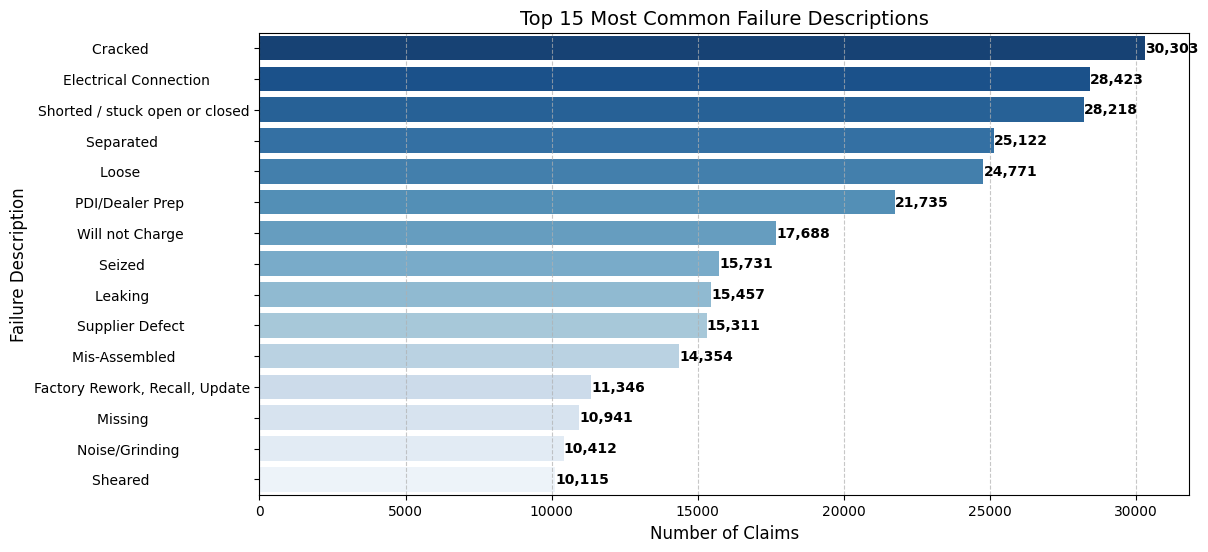

In [18]:
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.ticker as ticker

# Check frequency distribution of Failure Description
failure_counts = failure_part_cleaned_df['Failure Description'].value_counts().reset_index()
failure_counts.columns = ['Failure Description', 'Count']

# Analyze Failure Description vs. Total Claim Dollars
failure_costs = failure_part_cleaned_df.merge(claim_cleaned_df[['Claim Number', 'Total Claim Dollars']], on='Claim Number', how='left')
failure_cost_summary = failure_costs.groupby('Failure Description')['Total Claim Dollars'].sum().reset_index()
failure_cost_summary = failure_cost_summary.sort_values(by='Total Claim Dollars', ascending=False)

# Plot top 15 failure descriptions by claim count
plt.figure(figsize=(12, 6))
ax = sns.barplot(data=failure_counts.head(15), y='Failure Description', x='Count', palette='Blues_r')

# Add value labels on bars
for index, value in enumerate(failure_counts['Count'].head(15)):
    ax.text(value, index, f'{value:,}', va='center', ha='left', fontsize=10, fontweight='bold')

plt.xlabel('Number of Claims', fontsize=12)
plt.ylabel('Failure Description', fontsize=12)
plt.title('Top 15 Most Common Failure Descriptions', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()



## Plot top 15 failure descriptions by total claim dollars

<ipython-input-19-83d810256607>:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(data=failure_cost_summary.head(15), y='Failure Description', x='Total Claim Dollars', palette='Reds_r')


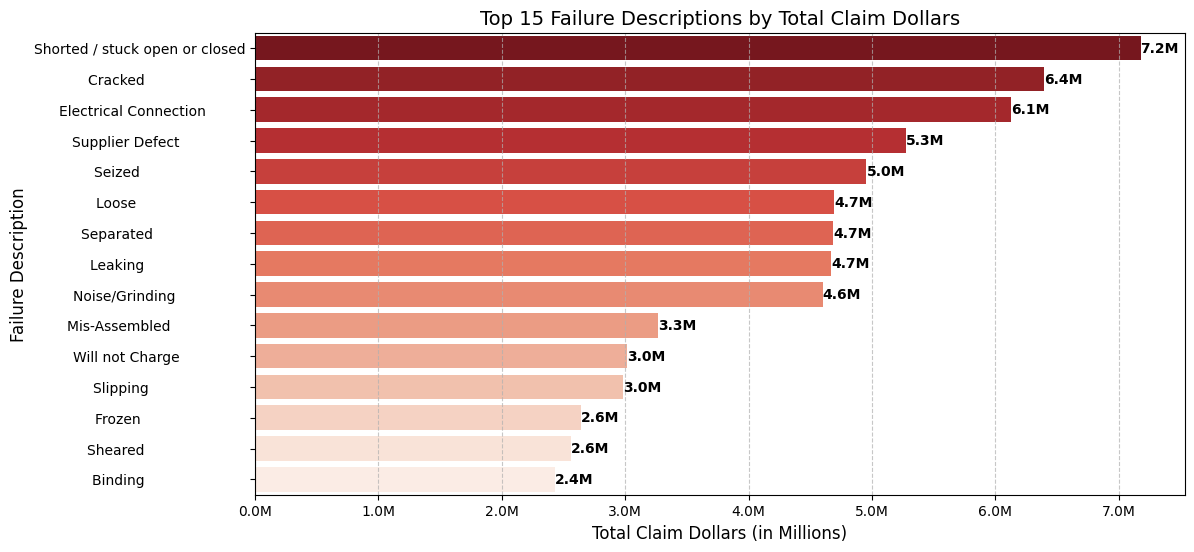

In [19]:

plt.figure(figsize=(12, 6))
ax = sns.barplot(data=failure_cost_summary.head(15), y='Failure Description', x='Total Claim Dollars', palette='Reds_r')

# Format x-axis to show values in millions
ax.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, pos: f'{x/1e6:.1f}M'))

# Add value labels on bars
for index, value in enumerate(failure_cost_summary['Total Claim Dollars'].head(15)):
    ax.text(value, index, f'{value/1e6:.1f}M', va='center', ha='left', fontsize=10, fontweight='bold')

plt.xlabel('Total Claim Dollars (in Millions)', fontsize=12)
plt.ylabel('Failure Description', fontsize=12)
plt.title('Top 15 Failure Descriptions by Total Claim Dollars', fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()


## Plot the top 15 Failure Parts by Total Claim Dollars

<ipython-input-20-405707b08e74>:22: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=failure_part_cost_summary.head(15), y='Failure Part', x='Total Claim Dollars', palette='Reds_r')


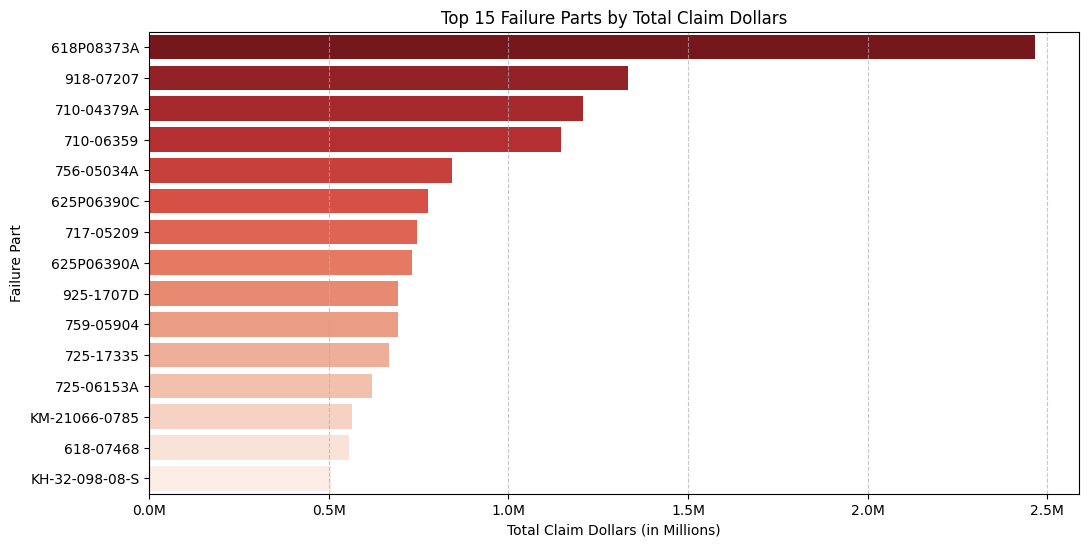

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# Merge failure part data with claim data to get total claim dollars
failure_costs = failure_part_cleaned_df.merge(claim_cleaned_df[['Claim Number', 'Total Claim Dollars']], on='Claim Number', how='left')

# Analyze failure cost distribution by Failure Part
failure_part_cost_summary = failure_costs.groupby('Failure Part')['Total Claim Dollars'].sum().reset_index()
failure_part_cost_summary = failure_part_cost_summary.sort_values(by='Total Claim Dollars', ascending=False)

#  Check if missing Failure Parts impact Total Claim Dollars
missing_failure_part_cost = failure_costs[failure_costs['Failure Part'].isnull()]['Total Claim Dollars'].sum()
total_claim_cost = failure_costs['Total Claim Dollars'].sum()
missing_part_percentage = (missing_failure_part_cost / total_claim_cost) * 100

# Look for common Failure Descriptions among missing parts
missing_failure_descriptions = failure_costs[failure_costs['Failure Part'].isnull()]['Failure Description'].value_counts().head(10)

# Plot top 15 failure parts contributing to total claims
plt.figure(figsize=(12, 6))
sns.barplot(data=failure_part_cost_summary.head(15), y='Failure Part', x='Total Claim Dollars', palette='Reds_r')
plt.xlabel('Total Claim Dollars (in Millions)')
plt.ylabel('Failure Part')
plt.title('Top 15 Failure Parts by Total Claim Dollars')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.gca().xaxis.set_major_formatter(plt.FuncFormatter(lambda x, loc: f'{x/1e6:.1f}M'))  # Format y-axis in millions
plt.show()

# Display the results
missing_data_summary = pd.DataFrame({
    'Metric': ['Total Claim Dollars from Missing Failure Parts', 'Percentage of Total Claims'],
    'Value': [missing_failure_part_cost, missing_part_percentage]
})

## Plot the top vendors with most problematic parts

<ipython-input-21-3b86cd81e11e>:18: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(x='Vendor Number', y='Claim Number', data=top_vendors, palette='Reds_r')


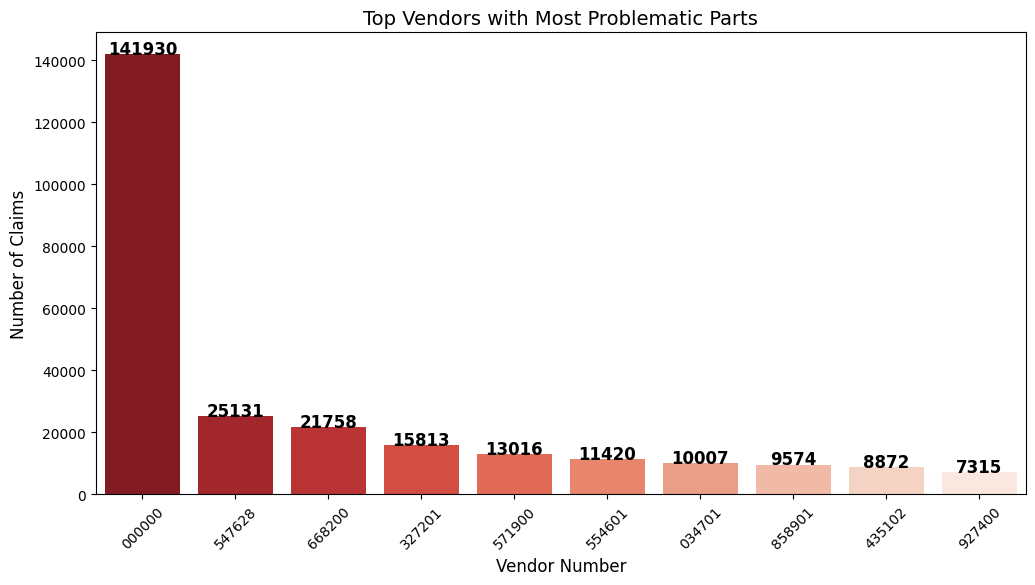

In [21]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the number of claims per vendor
top_vendors = failure_part_cleaned_df.groupby('Vendor Number')['Claim Number'].nunique().reset_index()

top_vendors.head()

# Sort the values by the number of claims in descending order to get the top vendors
top_vendors = top_vendors.sort_values('Claim Number', ascending=False).head(10)

# Format vendor numbers to be exactly 6 digits with leading zeros and remove decimals
top_vendors['Vendor Number'] = top_vendors['Vendor Number'].astype(int).astype(str).str.zfill(6)

# Plotting
plt.figure(figsize=(12, 6))
bar_plot = sns.barplot(x='Vendor Number', y='Claim Number', data=top_vendors, palette='Reds_r')

# Labels and title
plt.xlabel('Vendor Number', fontsize=12)
plt.ylabel('Number of Claims', fontsize=12)
plt.title('Top Vendors with Most Problematic Parts', fontsize=14)
plt.xticks(rotation=45)

# Add data labels on top of bars
for i, value in enumerate(top_vendors['Claim Number']):
    plt.text(i, value + 50, str(value), ha='center', fontsize=12, fontweight='bold')

plt.show()


## Plot the Top 15 Most Frequently Replaced Parts by Number of claims

<ipython-input-22-5ed4df6b9e4f>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_replaced_parts.index, x=top_replaced_parts.values, palette='Blues_r')


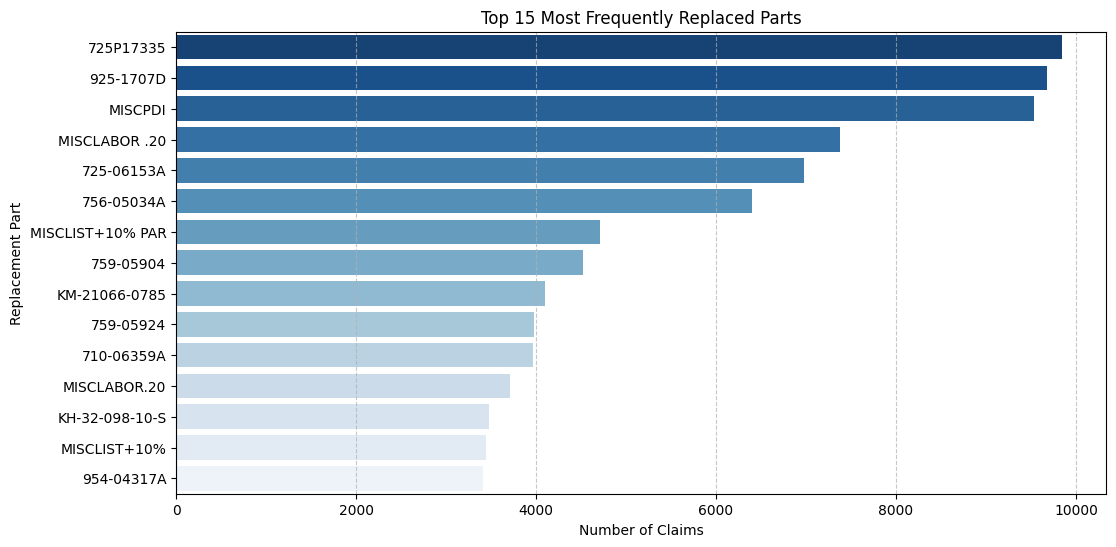

In [22]:
# Most Frequently Replaced Parts
top_replaced_parts = replacement_part_cleaned_df['Replacement Part'].value_counts().head(15)
plt.figure(figsize=(12, 6))
sns.barplot(y=top_replaced_parts.index, x=top_replaced_parts.values, palette='Blues_r')
plt.xlabel('Number of Claims')
plt.ylabel('Replacement Part')
plt.title('Top 15 Most Frequently Replaced Parts')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Plot the Costliest Replacement Parts by Total Failure Cost

<ipython-input-23-ecd3ae2de2d5>:4: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=top_costly_parts.index, x=top_costly_parts.values, palette='Reds_r')


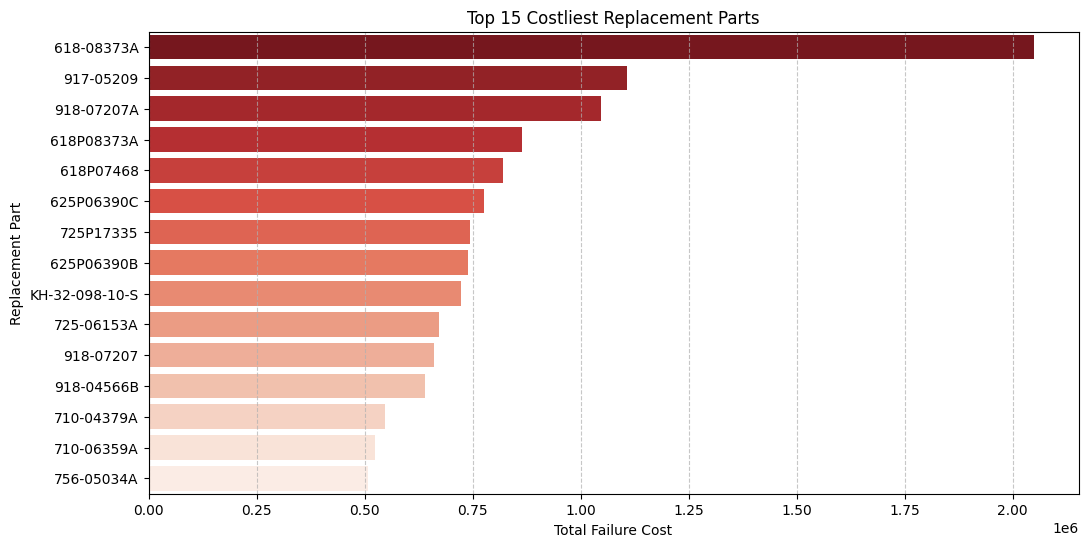

In [23]:
# Costliest Replacement Parts
top_costly_parts = replacement_part_cleaned_df.groupby('Replacement Part')['Total Failure Cost'].sum().nlargest(15)
plt.figure(figsize=(12, 6))
sns.barplot(y=top_costly_parts.index, x=top_costly_parts.values, palette='Reds_r')
plt.xlabel('Total Failure Cost')
plt.ylabel('Replacement Part')
plt.title('Top 15 Costliest Replacement Parts')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

## Top 15 Replacement Parts by Average Failure Cost per claim number

<ipython-input-24-358a4049e4af>:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(y=avg_failure_cost_per_part['Replacement Part'], x=avg_failure_cost_per_part['Total Failure Cost'], palette='Reds_r')


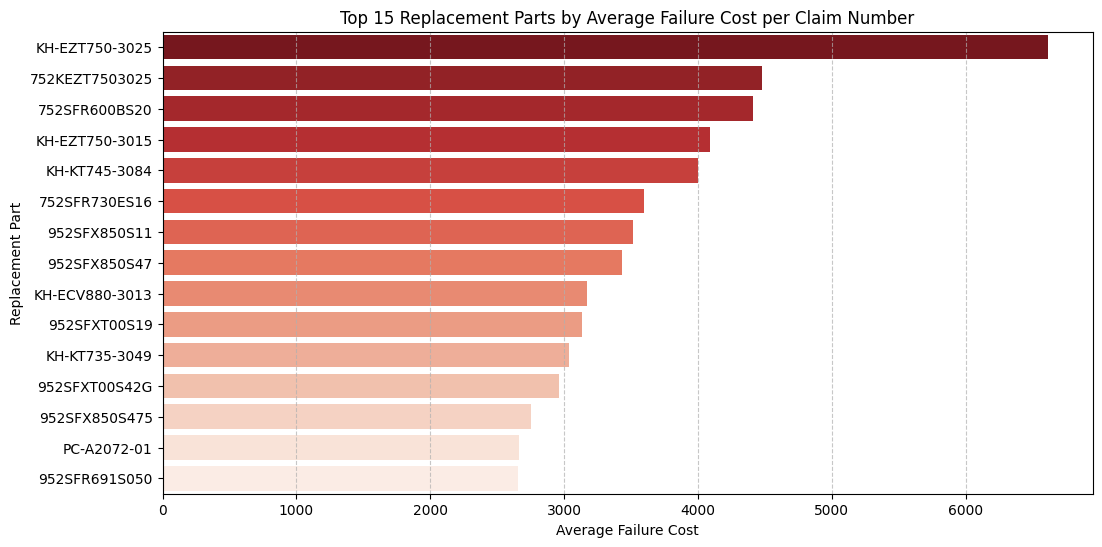

In [24]:
# Group by Replacement Part and Claim Number to calculate the average failure cost per replacement part
avg_failure_cost_per_part = (
    replacement_part_cleaned_df.groupby('Replacement Part')['Total Failure Cost']
    .mean()
    .nlargest(15)
    .reset_index()
)

# Plotting the top 15 replacement parts by average failure cost per claim number
plt.figure(figsize=(12, 6))
sns.barplot(y=avg_failure_cost_per_part['Replacement Part'], x=avg_failure_cost_per_part['Total Failure Cost'], palette='Reds_r')

# Labels and title
plt.xlabel('Average Failure Cost')
plt.ylabel('Replacement Part')
plt.title('Top 15 Replacement Parts by Average Failure Cost per Claim Number')
plt.grid(axis='x', linestyle='--', alpha=0.7)

# Show plot
plt.show()
